In [17]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import APSIMGraphHelpers as AGH
import GraphHelpers as GH
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.dates as mdates
import MathsUtilities as MUte
import shlex # package to construct the git command to subprocess format
import subprocess 
import xmltodict, json
import sqlite3
from scipy.optimize import basinhopping
from scipy.optimize import dual_annealing
from skopt import gp_minimize
%matplotlib inline

In [18]:
Colors = {1:'#000000',
2:'#E69F00',
3:'#56B4E9',
4:'#009E73',
5:'#F0E442',
6:'#0072B2',
7:'#D55E00',
8:'#CC79A7',
9:'#1F77B4',
10:'#AEC7E8',
11:'#FF7F0E',
12:'#FFBB78',
13:'#2CA02C',
14:'#98DF8A',
15:'#D62728',
16:'#FF9896',
17:'#9467BD',
18:'#C5B0D5',
19:'#8C564B',
20:'#C49C94',
21:'#E377C2',
22:'#F7B6D2',
23:'#7F7F7F',
24:'#C7C7C7',
25:'#BCBD22',
26:'#DBDB8D',
27:'#17BECF',
28:'#9EDAE5'}

Markers = {1: 'o',
 2: '^',
 3: 's',
 4: '*',
 5: '>',
 6: 'v',
 7: '+',
 8: 'X',
 9: '<',
 10: 'p',
 11: '8',
 12: 'd',
 13:'P',
 14:'D',
 15:'o',
 16:'^'}

Lines = {1: '-',
 2: '--',
 3: '-,',
 4: ':',
 5: '-',
 6: '--',
 7: '-,',
 8: ':',
 9: '-',
 10: '--',
 11: '-,',
 12: ':',
 13: '-',
 14: '--',
 15: '-,',
 16: ':'}

In [19]:
MasterfilePath = r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat.db'
DevfilePath = r'C:\GitHubRepos\ApsimX\Prototypes\WheatSimpleLeaf\WheatSL.db'
VariableRenamesFile = 'C:\GitHubRepos\ApsimX\Prototypes\WheatSimpleLeaf\SimpleLeafImplementation\VariableRenames.xlsx'
VRsheetname =  'SimpleLeafRenames'
VariableRenames = pd.read_excel(VariableRenamesFile,index_col=0, sheet_name='SimpleLeafRenames').to_dict()['SimpleLeaf']

In [20]:
SensibilityFolders = ['CO2AndTranspirationEfficiency',
'CO2AndTemperatureInteractions',
'ProteinAccumulation',
'LeafAppearance',
'TerminalWaterStress',
'DetailedDynamics']

In [21]:
#Set up simulations index table
def setSimulations(filePath):
    con = sqlite3.connect(filePath)
    Simulations = pd.read_sql("Select * from _Simulations",con)
    Simulations.set_index('ID',inplace=True)
    Simulations.sort_index(inplace=True)
    Simulations.sort_index(inplace=True, axis=1)
    con.close()
    return Simulations

MasterSimulations = setSimulations(MasterfilePath)
DevSimulations = setSimulations(DevfilePath)

In [22]:
#Set up sowing report 
def setSowingReport(filePath,Simulations):
    con = sqlite3.connect(filePath)
    SowingReport = pd.read_sql("Select * from SowingReport",con)
    SowingReport.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in SowingReport.SimulationID]
    SowingReport.set_index(['SimulationName'],drop=False,inplace=True)
    SowingReport.sort_index(inplace=True)
    SowingReport.sort_index(inplace=True,axis=1)
    con.close()
    
    # Filter outputs from sensibility tests
    validationFilter = [x not in SensibilityFolders for x in SowingReport.FolderName]
    SowingReport = SowingReport.loc[validationFilter,:].copy()
    SowingReport.dropna(how='all',axis=1,inplace=True)
    
    #Where Experiment is None (i.e a single simulation) use folder name instead)
    SowingReport.loc[[x is None for x in SowingReport.Experiment],'Experiment'] = SowingReport.loc[[x is None for x in SowingReport.Experiment],'FolderName']

    return SowingReport

MasterSowingReport = setSowingReport(MasterfilePath,MasterSimulations)
DevSowingReport = setSowingReport(DevfilePath,DevSimulations)

In [23]:
#Set up additional index table
def makeLists(SowingReport):
    Latitudes = list(SowingReport.loc[:,'IWeather.Latitude'].drop_duplicates().values)
    Latitudes.sort()
    Longitudes = list(SowingReport.loc[:,'IWeather.Longitude'].drop_duplicates().values)
    Longitudes.sort()
    Countries = list(SowingReport.loc[:,'LocationInfo.Script.Country'].drop_duplicates().values)
    Regions = list(SowingReport.loc[:, 'LocationInfo.Script.Region'].drop_duplicates().values)
    States = list(SowingReport.loc[:,'LocationInfo.Script.State'].drop_duplicates().values)
    Cultivars = list(SowingReport.loc[:,'Wheat.SowingData.Cultivar'].drop_duplicates().values)
    Cultivars.sort()
    Experiments = list(SowingReport.loc[:,'Experiment'].drop_duplicates().values)
    Folders = list(SowingReport.loc[:,'FolderName'].drop_duplicates().values)
    return Latitudes, Longitudes, Countries, Regions, States, Cultivars, Experiments, Folders

Masterlatitudes, MasterLongitudes, MasterCountries, MasterRegions, MasterStages, MasterCultivars, MasterExperiments, MasterFolders = makeLists(MasterSowingReport)
Devlatitudes, DevLongitudes, DevCountries, DevRegions, DevStages, DevCultivars, DevExperiments, DevFolders = makeLists(DevSowingReport)

In [24]:
SowIndices = ['IWeather.Latitude',
    'IWeather.Longitude',
    'LocationInfo.Script.Country',
    'LocationInfo.Script.Region',
    'LocationInfo.Script.State',
    'Wheat.SowingData.Cultivar',
    'Experiment',
    'FolderName']

def getValue(ind,var,SowingReport):
    try:
        return SowingReport.loc[ind,var].title()
    except:
        return ""

#read in observed datafile
def setObserved(filePath,Simulations,SowingReport):
    con = sqlite3.connect(filePath)
    Observed = pd.read_sql("Select * from Observed",con).dropna(axis=1,how='all')
    Observed.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in Observed.SimulationID]
    Observed.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    Observed.sort_index(inplace=True)
    Observed.sort_index(inplace=True,axis=1)
    con.close()
    
    for s in SowIndices:
        Observed.loc[:,s] = [getValue(x,s,SowingReport) for x in Observed.index.get_level_values(0)]
    return Observed

MasterObserved = setObserved(MasterfilePath, MasterSimulations, MasterSowingReport)
DevObserved = setObserved(DevfilePath, DevSimulations, DevSowingReport)

In [25]:
# read in predicted values output on harvest date
def setHarvestPred(filePath,Simulations,SowingReport):
    con = sqlite3.connect(filePath)
    HarvestPred = pd.read_sql("Select * from HarvestReport",con).dropna(axis=1,how='all')
    HarvestPred.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in HarvestPred.SimulationID]
    HarvestPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    HarvestPred.sort_index(inplace=True)
    HarvestPred.sort_index(inplace=True,axis=1)
    con.close()
    # Filter outputs from sensibility tests
    validationFilter = [x not in SensibilityFolders for x in HarvestPred.FolderName]
    HarvestPred = HarvestPred.loc[validationFilter,:].copy()
    HarvestPred.dropna(how='all',axis=1,inplace=True)
    # Replace Experiment with values that have had folder name pathed in where no experiment is present
    HarvestPred.loc[:,'Experiment'] = [SowingReport.loc[x,'Experiment'] for x in HarvestPred.index.get_level_values(0)]
    HarvestPred.loc[:,'Wheat.SowingData.Cultivar'] = [x.title() for x in HarvestPred.loc[:,'Wheat.SowingData.Cultivar']]
    return HarvestPred

MasterHarvestPred = setHarvestPred(MasterfilePath, MasterSimulations, MasterSowingReport)
DevHarvestPred = setHarvestPred(DevfilePath, DevSimulations, DevSowingReport)

In [26]:
# read in daily predicted values
def setDailyPred(filePath, Simulations, SowingReport):
    con = sqlite3.connect(filePath)
    DailyPred = pd.read_sql("Select * from DailyReport",con)
    con.close()
    DailyPred.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in DailyPred.SimulationID]
    DailyPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    DailyPred.sort_index(inplace=True)
    DailyPred.sort_index(inplace=True,axis=1)
    validationFilter = [x not in SensibilityFolders for x in DailyPred.FolderName]
    DailyPred = DailyPred.loc[validationFilter,:].copy()
    DailyPred.dropna(how='all',axis=1,inplace=True)
    # Replace Experiment with values that have had folder name pathed in where no experiment is present
    DailyPred.loc[:,'Experiment'] = [SowingReport.loc[x,'Experiment'] for x in DailyPred.index.get_level_values(0)]
    
    ## Join NDVI data into daily obs
    con = sqlite3.connect(filePath)
    NDVIPred = pd.read_sql("Select * from NDVIDailyReport",con)
    con.close()
    NDVIPred.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in NDVIPred.SimulationID]
    NDVIPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
    NDVIPred.sort_index(inplace=True)
    NDVIPred.sort_index(inplace=True,axis=1)
    
    validationFilter = [x not in SensibilityFolders for x in NDVIPred.FolderName]
    NDVIPred = NDVIPred.loc[validationFilter,:].copy()
    NDVIPred.dropna(how='all',axis=1,inplace=True)
    ##Join NDVI predictions in with others 
    for i in NDVIPred.index:
        DailyPred.loc[i,'NDVIModel.Script.NDVI'] = NDVIPred.loc[i,'NDVIModel.Script.NDVI']

    return DailyPred

MasterDailyPred = setDailyPred(MasterfilePath, MasterSimulations, MasterSowingReport)
DevDailyPred = setDailyPred(DevfilePath, DevSimulations, DevSowingReport)

In [27]:
#Make table of Observations tagged with a 'Wheat.Phenology.CurrentStageName' value equal to 'HarvestRipe' which indicates it is the final harvest value
MasterHarvestObs = MasterObserved.loc[MasterObserved.loc[:,'Wheat.Phenology.CurrentStageName']=='HarvestRipe',:].dropna(axis=1,how='all').dropna(axis=0,how='all')
DevHarvestObs = DevObserved.loc[DevObserved.loc[:,'Wheat.Phenology.CurrentStageName']=='HarvestRipe',:].dropna(axis=1,how='all').dropna(axis=0,how='all')
HarvVars = ['Wheat.AboveGround.N',
'Wheat.AboveGround.NConc',
'Wheat.AboveGround.Wt',
'Wheat.Ear.N',
'Wheat.Ear.NConc',
'Wheat.Ear.Wt',
'Wheat.Grain.N',
'Wheat.Grain.NConc',
'Wheat.Grain.Number',
'Wheat.Grain.Protein',
'Wheat.Grain.Size',
'Wheat.Grain.Wt',
'Wheat.Leaf.N',
'Wheat.Leaf.StemPopulation',
'Wheat.Leaf.Wt',
'Wheat.Phenology.CAMP.TSHS',
'Wheat.Phenology.EmergenceDAS',
'Wheat.Phenology.FinalLeafNumber',
'Wheat.Phenology.FlagLeafDAS',
'Wheat.Phenology.FloweringDAS',
'Wheat.Phenology.HeadingDAS',
'Wheat.Phenology.MaturityDAS',
'Wheat.Phenology.TerminalSpikeletDAS',
'Wheat.Spike.HeadNumber',
'Wheat.Spike.N',
'Wheat.Spike.Wt',
'Wheat.Stem.N',
'Wheat.Stem.NConc',
'Wheat.Stem.Wt']

In [28]:
MasterHarvest = {"obs":MasterHarvestObs,"pred":MasterHarvestPred}
DevHarvest = {"obs":DevHarvestObs,"pred":DevHarvestPred}
Pair = {"master":MasterHarvest,"dev":DevHarvest}

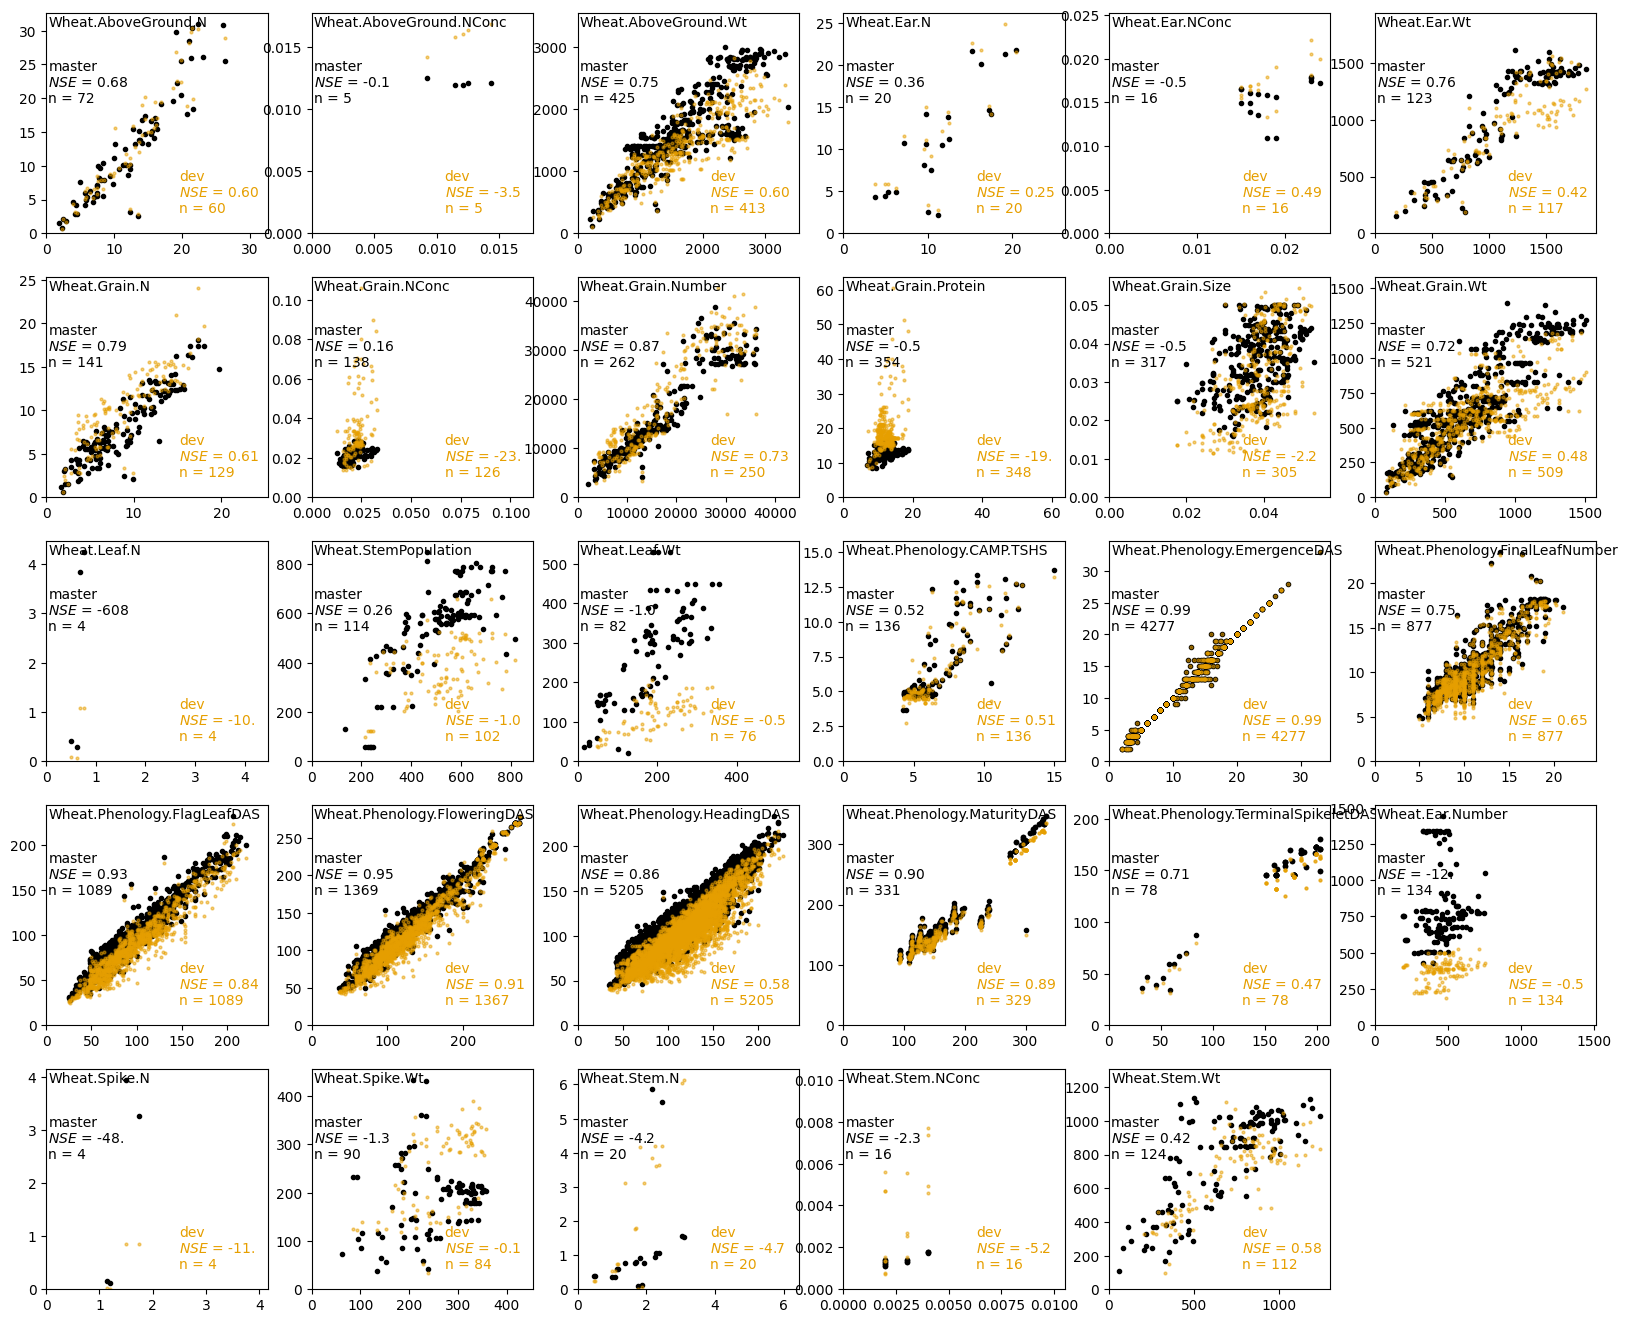

In [29]:
legpos = {"master":[0.01,0.79],"dev":[0.6,0.29]}
HarvGraphs =  plt.figure(figsize=(20,20))
pos=1
for var in HarvVars:
    ax = HarvGraphs.add_subplot(6,6,pos)
    axmax = 0.01
    cpos = 1
    msv = 3
    alpv = 1
    for p in Pair:
        if p=='dev' and var in list(VariableRenames.keys()):
            var = VariableRenames[var]
        obsPred = pd.DataFrame(Pair[p]["obs"].loc[:,var].dropna().copy())
        obsPred.columns = ['obs']
        obsPred.index = obsPred.index.get_level_values(0)
        for s in obsPred.index:
            try:
                obsPred.loc[s,'pred'] = Pair[p]["pred"].loc[s,var].values[0]
            except:
                obsPred.loc[s,'pred'] = np.nan
        obsPred.dropna(inplace=True)
        plt.plot(obsPred.obs,obsPred.pred,'o',ms = msv,color = Colors[cpos],alpha = alpv)
        
        if len(obsPred.pred.dropna())>2:
                n = len(obsPred.obs)
                RegStats = MUte.MathUtilities.CalcRegressionStats('',obsPred.pred,obsPred.obs)
                fitR2 = p+'\n$NSE$ = ' + str(RegStats.NSE)[:4] + '\nn = '+ str(n)
                plt.text(legpos[p][0],legpos[p][1],fitR2,transform=ax.transAxes,horizontalalignment='left', verticalalignment='top',color = Colors[cpos])
                
        if len(obsPred.pred.dropna())>0:
            axmax = max(obsPred.obs.max(),obsPred.pred.max(),axmax)
        cpos +=1
        msv -=1
        alpv *= 0.5
    plt.text(0.01,0.99,var,transform=ax.transAxes,horizontalalignment='left', verticalalignment='top')
    
    plt.ylim(0,axmax*1.05)
    plt.xlim(0,axmax*1.05)   
    pos+=1

In [30]:
def subVarName(name):
    varName = name
    try:
        varName = VariableRenames[name]
        return varName
    except:
        return varName

MasterDailyObsIndices = ['Clock.Today',
                'Wheat.Phenology.CurrentStageName',
                'IWeather.Latitude',
                'IWeather.Longitude',
                'LocationInfo.Script.Country',
                'LocationInfo.Script.Region',
                'LocationInfo.Script.State',
                'Wheat.SowingData.Cultivar',
                'Experiment',
                'FolderName']

DevDailyObsIndices = [subVarName(x) for x in MasterDailyObsIndices]

MasterDailyObsVars = ['NDVIModel.Script.NDVI',
                'Wheat.AboveGround.N',
                'Wheat.AboveGround.NConc',
                'Wheat.AboveGround.Wt',
                'Wheat.Ear.N',
                'Wheat.Ear.NConc',
                'Wheat.Ear.Wt',
                'Wheat.Grain.N',
                'Wheat.Grain.NConc',
                'Wheat.Grain.Wt',
                'Wheat.Leaf.CoverGreen',
                'Wheat.Leaf.CoverTotal',
                'Wheat.Leaf.Dead.N',
                'Wheat.Leaf.Dead.NConc',
                'Wheat.Leaf.Dead.Wt',
                'Wheat.Leaf.Height',
                'Wheat.Leaf.LAI',
                'Wheat.Leaf.Live.N',
                'Wheat.Leaf.Live.NConc',
                'Wheat.Leaf.Live.StorageWt',
                'Wheat.Leaf.Live.Wt',
                'Wheat.Leaf.N',
                'Wheat.Leaf.SpecificAreaCanopy',
                'Wheat.Leaf.StemNumberPerPlant',
                'Wheat.Leaf.StemPopulation',
                'Wheat.Leaf.Wt',
                'Wheat.Phenology.HaunStage',
                'Wheat.Phenology.Zadok.Stage',
                'Wheat.Spike.N',
                'Wheat.Spike.NConc',
                'Wheat.Spike.Live.StorageWt',
                'Wheat.Spike.Wt',
                'Wheat.Stem.N',
                'Wheat.Stem.NConc',
                'Wheat.Stem.Live.StorageWt',
                'Wheat.Stem.Wt',
                '(Wheat.Leaf.Transpiration + ISoilWater.Es + MicroClimate.PrecipitationInterception)',
                'sum(Soil.Water.MM)',
                'Soil.Water.Volumetric(1)']

DevDailyObsVars = [subVarName(x) for x in MasterDailyObsVars]

MasterDailyObsIndicesAndVars = MasterDailyObsIndices+MasterDailyObsVars
DevDailyObsIndicesAndVars = DevDailyObsIndices+DevDailyObsVars

MasterDailyObs = MasterObserved.loc[~MasterObserved.loc[:,'Clock.Today'].isnull(),MasterDailyObsIndicesAndVars]
MasterDailyObs.dropna(axis=1,how="all",inplace=True)
MasterDailyObs.dropna(axis=0,how="all",inplace=True)

DevDailyObs = DevObserved.loc[~DevObserved.loc[:,'Clock.Today'].isnull(),DevDailyObsIndicesAndVars]
DevDailyObs.dropna(axis=1,how="all",inplace=True)
DevDailyObs.dropna(axis=0,how="all",inplace=True)

In [31]:
MasterIndexVars = ['Clock.Today',
'IWeather.MaxT',
'IWeather.MinT',
'IWeather.Radn',
'SimulationID',
'SimulationName',
'Wheat.DaysAfterSowing',
'Wheat.Phenology.AccumulatedTT',
'Wheat.Phenology.CurrentPhase.Name',
'Wheat.Phenology.CurrentStageName',
'Wheat.Phenology.Stage']

DevIndexVars = [subVarName(x) for x in MasterIndexVars]

for iv in MasterIndexVars:
    MasterDailyObs.loc[:,iv] = MasterDailyPred.reindex(MasterDailyObs.index).loc[:,iv]
    
for iv in DevIndexVars:
    DevDailyObs.loc[:,iv] = DevDailyPred.reindex(DevDailyObs.index).loc[:,iv]
    
MasterDailyResidules = MasterDailyObs.copy()
DevDailyResidules = DevDailyObs.copy()
for ov in MasterDailyObsVars:
    MasterDailyResidules.loc[:,ov] = MasterDailyObs.loc[:,ov] - MasterDailyPred.reindex(MasterDailyObs.index).loc[:,ov]
for ov in DevDailyObsVars:
    DevDailyResidules.loc[:,ov] = DevDailyObs.loc[:,ov] - DevDailyPred.reindex(DevDailyObs.index).loc[:,ov]

KeyError: '(Wheat.Leaf.Transpiration + ISoilWater.Es + MicroClimate.PrecipitationInterception)'

In [ ]:
#Make data frame with factor information for each simulation
FactorList = [ 'Experiment',
 'Canopy',
 'Cm',
 'Cultivar',
 'Cv',
 'Date',
 'Durat',
 'Fungicide',
 'Grazed',
 'Irr',
 'Irrig',
 'Mgmt',
 'N',
 'NRate',
 'Nit',
 'Nutrition',
 'P',
 'PGR',
 'Popn',
 'Removal',
 'RowSpace',
 'SD',
 'Seeds',
 'Soil',
 'Sow',
 'SowN',
 'Stubble',
 'TOS',
 'TopN',
 'Treat',
 'Treatment',
 'V',
 'Water']

Factors = HarvestPred.loc[:,FactorList].copy()
Factors.index = Factors.index.droplevel(1)
Factors.set_index('Experiment',append=True,inplace=True)
Factors=Factors.reorder_levels(['Experiment','SimulationName'])
Factors.sort_index(inplace=True)
CondensedFactors = pd.DataFrame(index = Factors.index,columns = ['fName1','fValue1'])
for s in Factors.index:
    fs = Factors.loc[s,:].dropna().to_dict()
    fCount = 1
    for key, value in fs.items():
        CondensedFactors.loc[s,'fName'+str(fCount)] = key
        CondensedFactors.loc[s,'fValue'+str(fCount)] = value
        fCount +=1
valueLabs = ['fValue1','fValue2','fValue3','fValue4']
indexLabs = ['fIndex1','fIndex2','fIndex3','fIndex4']
CondensedFactors.loc[:,indexLabs]=1

# put simulation names in as first factor level for sims that are not in a experiment
for e in Experiments:
    fValues1 = CondensedFactors.loc[e,'fValue1']
    if True in pd.isna(fValues1.values):
        CondensedFactors.loc[e,'fValue1'] = CondensedFactors.loc[e,:].index.values
        
#assign numeric index to each factor level
for e in Experiments:
    for v in valueLabs:
        fLevels = CondensedFactors.loc[e,v].drop_duplicates().values
        if False in pd.isna(fLevels):
            levelDic = dict(zip(fLevels,list(range(1,len(fLevels )+1))))
            CondensedFactors.loc[e,v.replace('Value','Index')] = [levelDic[x] for x in CondensedFactors.loc[e,v]]

In [ ]:
def residualGraph(ind,var,gro,figsize = (20,10),legends=True):
    Graph = plt.figure(figsize=figsize)
    ax = Graph.add_subplot(1,1,1)
    plotSet = DailyResidules.dropna(subset=[ind,var]).loc[:,[ind,var,gro]]
    Groups = list(plotSet.Experiment.drop_duplicates().values)
    colPos = 1
    markerPos = 1
    for g in Groups:
        groupSet = plotSet.loc[plotSet.loc[:,gro] == g,:]
        SimsToGraph = list(groupSet.index.get_level_values(0).drop_duplicates())
        for s in SimsToGraph:
            data = DailyResidules.loc[s,[ind,var]].dropna()
            x = data.loc[:,ind]
            y = data.loc[:,var]
            plt.plot(x,y,Markers[markerPos]+'-',lw=1,ms=10,color = Colors[colPos],label=g)
        colPos +=1
        if colPos>8:
            colPos=1
            markerPos +=1
    plt.ylabel(var+" (Obs - Pred)")
    plt.xlabel(ind)
    if legends == True:
        GH.AddLegend(LegLoc=1,labelsize=12,Title='Experiment')
    Graph.close()
def timeSeriesGraph(ind,var,gro,figsize = (20,20),legends=False,cols=6,yfix=True):
    Graph = plt.figure(figsize=figsize)
    plotSet = DailyResidules.dropna(subset=[ind,var]).loc[:,[ind,var,gro]]
    ymax = max(DailyObs.loc[:,var].max(),DailyPred.loc[:,var].max())*1.01
    Groups = list(plotSet.Experiment.drop_duplicates().values)
    colPos = 1
    Pos = 1
    rows = int(np.ceil(len(Groups)/cols))
    for g in Groups:
        markerPos = 1
        ax = Graph.add_subplot(rows,cols,Pos)
        groupSet = plotSet.loc[plotSet.loc[:,gro] == g,:]
        SimsToGraph = list(groupSet.index.get_level_values(0).drop_duplicates())
        for s in SimsToGraph:
            scol = Colors[CondensedFactors.loc[(g,s),'fIndex1']]
            slin = Lines[CondensedFactors.loc[(g,s),'fIndex2']]
            smar = Markers[CondensedFactors.loc[(g,s),'fIndex2']]
            obs = DailyObs.loc[s,[ind,var]].dropna()
            obsX = obs.loc[:,ind]
            obsY = obs.loc[:,var]
            plt.plot(obsX,obsY,smar,ms=5,color = scol,label=s.replace(g,''))
            pred = DailyPred.loc[s,[ind,var]].dropna()
            predX = pred.loc[:,ind].where( pred.loc[:,ind] > 1.0,np.nan)
            predY = pred.loc[:,var]
            plt.plot(predX,predY,slin,lw=1,color = scol)
            markerPos +=1
            if markerPos >12:
                markerPos = 1
        if yfix == True:
            plt.ylim(0,ymax)
        plt.text(0.01,0.99,g,horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
        Pos +=1
        colPos +=1
        if colPos>8:
            colPos=1
        plt.ylabel(var)
        if legends == True:
            GH.AddLegend(LegLoc=2,labelsize=12,Title='Experiment')
    Graph.close()

def makeGraphs(var,height,yfix):
    residualGraph(ind = 'Wheat.Phenology.Stage',
              var = var,
              gro = 'Experiment',
              figsize = (20,5))
    timeSeriesGraph(ind = 'Wheat.Phenology.Stage',
                var = var,
                gro = 'Experiment',
                figsize = (20,height),yfix=yfix)

In [ ]:
for var in dailyObsVars:
    try:
        makeGraphs(var,height = 10,yfix=True)
    except:
        do = 'Proceed'

In [ ]:
list(HarvestObs.columns)

In [ ]:
Cultivars = list(HarvestObs.loc[:,"Wheat.SowingData.Cultivar"].drop_duplicates())
Cultivars.sort()

In [ ]:
DevVars = ['Wheat.Phenology.FinalLeafNumber',
'Wheat.Phenology.FlagLeafDAS',
'Wheat.Phenology.HeadingDAS',
'Wheat.Phenology.FloweringDAS',
'Wheat.Phenology.MaturityDAS']

In [ ]:
DevGraphs =  plt.figure(figsize=(20,300))
pos=1
for c in Cultivars:
    hpos = 1
    for var in DevVars:
        ax = DevGraphs.add_subplot(len(Cultivars),5,pos)
        cFilt = HarvestObs.loc[:,"Wheat.SowingData.Cultivar"] == c
        obsPred = pd.DataFrame(HarvestObs.loc[cFilt,var].dropna().copy())
        obsPred.columns = ['obs']
        obsPred.index = obsPred.index.get_level_values(0)
        for s in obsPred.index:
            try:
                obsPred.loc[s,'pred'] = HarvestPred.loc[s,var].values[0]
            except:
                obsPred.loc[s,'pred'] = np.nan
        obsPred.dropna(inplace=True)
        plt.text(0.01,0.89,c,transform=ax.transAxes,horizontalalignment='left', verticalalignment='top',weight='bold')
        if (len(obsPred.obs)>0):
            plt.plot(obsPred.obs,obsPred.pred,'o',ms = 2)
            plt.text(0.01,0.99,var,transform=ax.transAxes,horizontalalignment='left', verticalalignment='top')
            amax = 1
            if len(obsPred.pred.dropna())>2:
                RegStats = MUte.MathUtilities.CalcRegressionStats('',obsPred.pred,obsPred.obs)
                fitR2 = '$RMSE$ = ' + str(RegStats.RMSE)[:4]\
                  + '\n$Bias$ = ' + str(RegStats.ME)[:4] \
                  + '\n$NSE$ = ' + str(RegStats.NSE)[:4]\
                  #+ '\n$R^2$ = ' + str(RegStats.R2)[:4]
                plt.text(0.01,0.79,fitR2,transform=ax.transAxes,horizontalalignment='left', verticalalignment='top')
                n = len(obsPred.obs)
                plt.text(0.01,0.39,'n = '+ str(n),transform=ax.transAxes,horizontalalignment='left', verticalalignment='top')
                if len(obsPred.pred.dropna())>0:
                    axmax = max(obsPred.obs.max(),obsPred.pred.max())
            plt.ylim(0,axmax*1.05)
            plt.xlim(0,axmax*1.05)
            plt.plot([0,axmax],[0,axmax],'-',color='k')

        pos+=1